In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '../src')
from db import get_connection

conn = get_connection()
print("Connected to database")

Connected to database


In [2]:
query = """
    SELECT
        p.full_name,
        pgs.game_date,
        pgs.season,
        pgs.home_away,
        pgs.points,
        pgs.rebounds,
        pgs.assists,
        pgs.minutes_played,
        pgs.fg_made,
        pgs.fg_attempted,
        pgs.fg3_made,
        pgs.fg3_attempted
    FROM player_game_stats pgs
    JOIN players p ON pgs.player_id = p.player_id
    ORDER BY pgs.game_date DESC
"""
df = pd.read_sql(query, conn)
print(f"Total rows: {len(df)}")
print(f"Unique players: {df['full_name'].nunique()}")
df.head()

Total rows: 4870
Unique players: 44


/tmp/ipykernel_14419/3056922485.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,full_name,game_date,season,home_away,points,rebounds,assists,minutes_played,fg_made,fg_attempted,fg3_made,fg3_attempted
0,Tony Bradley,2025-04-13,22024,away,14,14,1,27.0,6,13,0,0
1,Grayson Allen,2025-04-13,22024,away,20,2,5,28.0,8,13,4,7
2,Trey Alexander,2025-04-13,22024,away,2,1,0,6.0,1,1,0,0
3,Nickeil Alexander-Walker,2025-04-13,22024,home,9,5,7,33.0,3,9,2,8
4,Cole Anthony,2025-04-13,22024,away,2,0,3,13.0,1,3,0,1


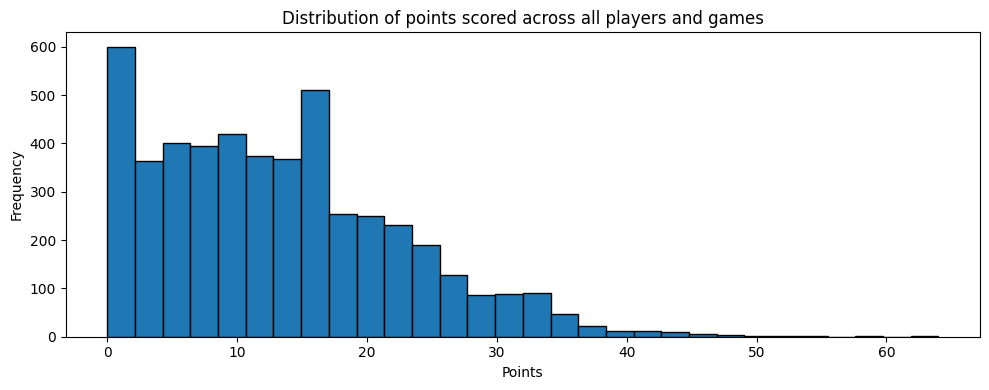

In [3]:
plt.figure(figsize=(10, 4))
plt.hist(df['points'], bins=30, edgecolor='black')
plt.title('Distribution of points scored across all players and games')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [4]:
home_avg = df[df['home_away'] == 'home']['points'].mean()
away_avg = df[df['home_away'] == 'away']['points'].mean()
print(f"Average points at home : {home_avg:.2f}")
print(f"Average points away    : {away_avg:.2f}")
print(f"Home advantage         : {home_avg - away_avg:.2f} pts")

Average points at home : 13.28
Average points away    : 13.17
Home advantage         : 0.11 pts


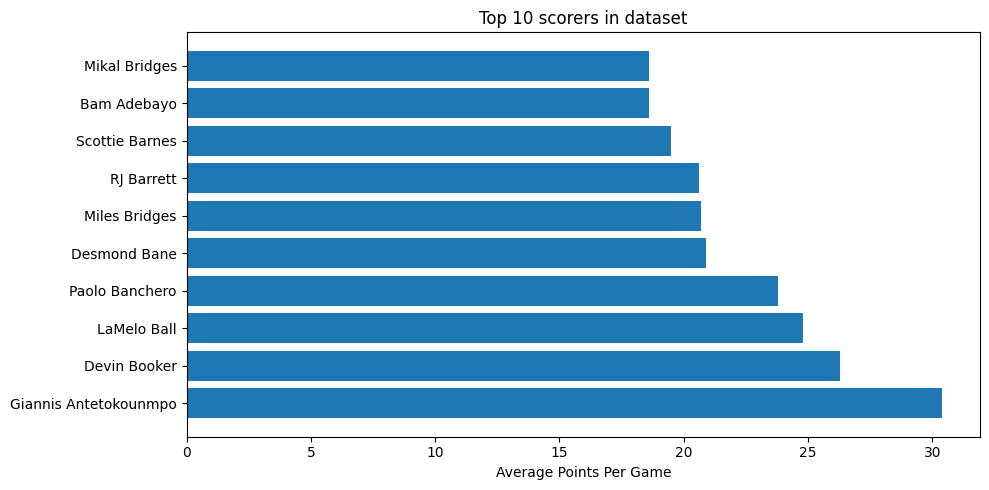

In [5]:
top_scorers = (
    df.groupby('full_name')['points']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)
top_scorers.columns = ['Player', 'Avg Points']
top_scorers['Avg Points'] = top_scorers['Avg Points'].round(1)

plt.figure(figsize=(10, 5))
plt.barh(top_scorers['Player'], top_scorers['Avg Points'])
plt.xlabel('Average Points Per Game')
plt.title('Top 10 scorers in dataset')
plt.tight_layout()
plt.show()

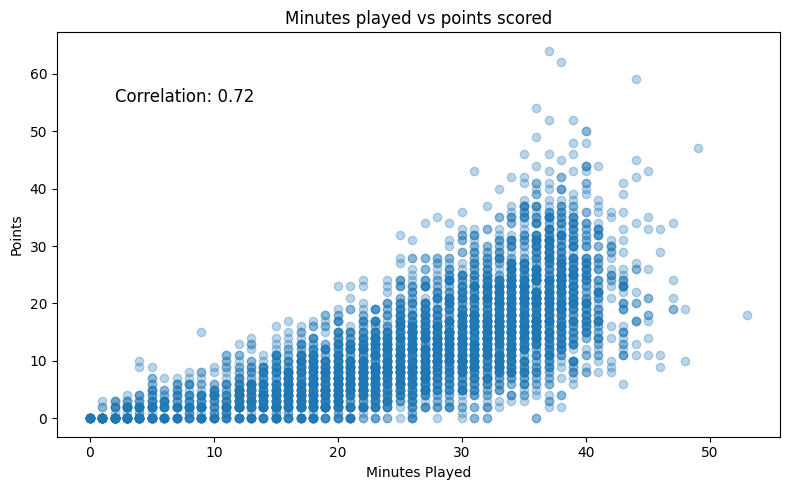

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df['minutes_played'], df['points'], alpha=0.3)
plt.xlabel('Minutes Played')
plt.ylabel('Points')
plt.title('Minutes played vs points scored')
correlation = df['minutes_played'].corr(df['points'])
plt.text(2, 55, f'Correlation: {correlation:.2f}', fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
season_avg = df.groupby('season')[['points', 'rebounds', 'assists']].mean().round(1)
print("Average stats by season:")
print(season_avg)

Average stats by season:
        points  rebounds  assists
season                           
22023     13.4       5.1      2.9
22024     13.1       5.0      2.9
